# 📊 Exploratory Data Analysis (EDA)
## Прогнозування відтоку клієнтів (Churn)

Мета : провести аналіз даних, виявити залежності та підготовити дані для дослідження.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import sys
print(sys.executable)

c:\Users\User\AppData\Local\Programs\Python\Python313\python.exe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
os.getcwd()

'c:\\Users\\User\\Downloads\\REPO\\customer-churn-prediction_project\\notebooks'

In [ ]:
import os
os.chdir('/content/drive/MyDrive/internet_churn_project/notebooks')
os.getcwd()

'/content/drive/MyDrive/internet_churn_project/notebooks'

# Відомі такі ознаки:

**id:** ID клієнта

**is_tv_subscriber:** чи має клієнт ТV підписку (0/1)

**is_movie_package_subscriber:** чи підписан клієнт на фільми (0/1)

**subscription_age:**  період часу клієнта з компанією

**bill_avg:** середній рахунок за послуги

**reamining_contract:** залишок часу по контракту клієнта

**service_failure_count:** кількість технічних збоїв

**download_avg:** download трафік

**upload_avg:** upload трафік

**download_over_limit:** кількість перевищень ліміту завантажень

**churn:** відтік (клієнт пішов чи залишився 0/1)

In [ ]:
# зчитуємо файл
df = pd.read_csv("../data/raw/internet_service_churn.csv")
df

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
72269,1689648,1,1,0.09,0,1.25,0,0.0,0.0,0,1
72270,1689676,1,0,0.06,1,1.63,0,0.8,0.0,0,1
72271,1689679,1,0,0.02,0,2.19,0,1.5,0.2,0,1
72272,1689733,0,0,0.01,0,0.72,0,0.0,0.0,0,1


In [ ]:
# Розмір датасету
df.shape


(72274, 11)

In [ ]:
# типи всіх стовпців
df.dtypes

,0
id,int64
is_tv_subscriber,int64
is_movie_package_subscriber,int64
subscription_age,float64
bill_avg,int64
reamining_contract,float64
service_failure_count,int64
download_avg,float64
upload_avg,float64
download_over_limit,int64


In [ ]:
# Загальна інформація про датасет
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   reamining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB


In [ ]:
# перевірка на дублікати
df.duplicated().sum()

np.int64(0)

In [ ]:
# Описова статистика
df.describe()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
count,7.227400e+04,72274.000000,72274.000000,72274.000000,72274.000000,50702.000000,72274.000000,71893.000000,71893.000000,72274.000000,72274.000000
mean,8.463182e+05,0.815259,0.334629,2.450051,18.942483,0.716039,0.274234,43.689911,4.192076,0.207613,0.554141
std,4.891022e+05,0.388090,0.471864,2.034990,13.215386,0.697102,0.816621,63.405963,9.818896,0.997123,0.497064
min,1.500000e+01,0.000000,0.000000,-0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.222165e+05,1.000000,0.000000,0.930000,13.000000,0.000000,0.000000,6.700000,0.500000,0.000000,0.000000
50%,8.477840e+05,1.000000,0.000000,1.980000,19.000000,0.570000,0.000000,27.800000,2.100000,0.000000,1.000000
75%,1.269562e+06,1.000000,1.000000,3.300000,22.000000,1.310000,0.000000,60.500000,4.800000,0.000000,1.000000
max,1.689744e+06,1.000000,1.000000,12.800000,406.000000,2.920000,19.000000,4415.200000,453.300000,7.000000,1.000000


In [ ]:
# Перевірка пропущених значень
df.isnull().sum()

,0
id,0
is_tv_subscriber,0
is_movie_package_subscriber,0
subscription_age,0
bill_avg,0
reamining_contract,21572
service_failure_count,0
download_avg,381
upload_avg,381
download_over_limit,0


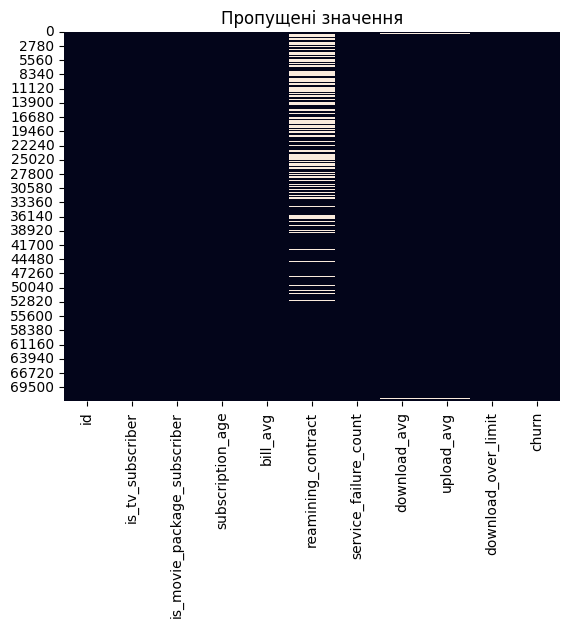

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Пропущені значення")
plt.show()

In [ ]:
# Аналіз цільової змінної на сбалансованість
df['churn'].value_counts(normalize=True)


,proportion
churn,
1,0.554141
0,0.445859


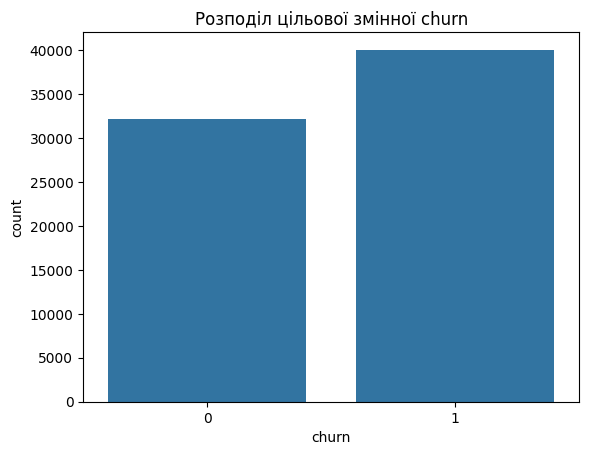

In [ ]:
# Візуалізація розподілу цільової змінної
sns.countplot(x='churn', data=df)
plt.title("Розподіл цільової змінної churn")
plt.show()

Розподіл цільової змінної показує, що класи відносно збалансовані (55% клієнтів пішли, 45% залишилися). Істотного дисбалансу немає, тому додаткові методи балансування (oversampling/undersampling) не потрібні.

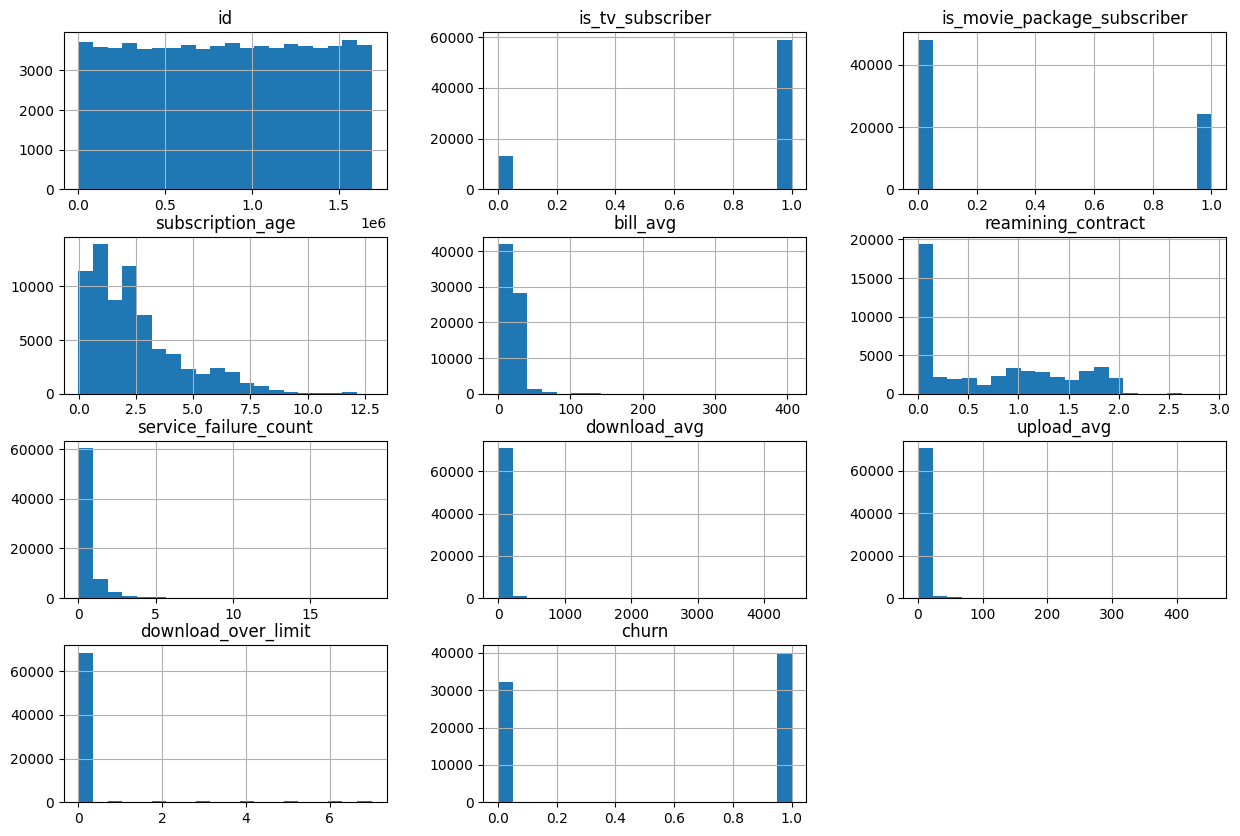

In [ ]:
# Розподіл ознак
df.hist(bins=20, figsize=(15,10))
plt.show()

# Аналіз можливих викидів в даних

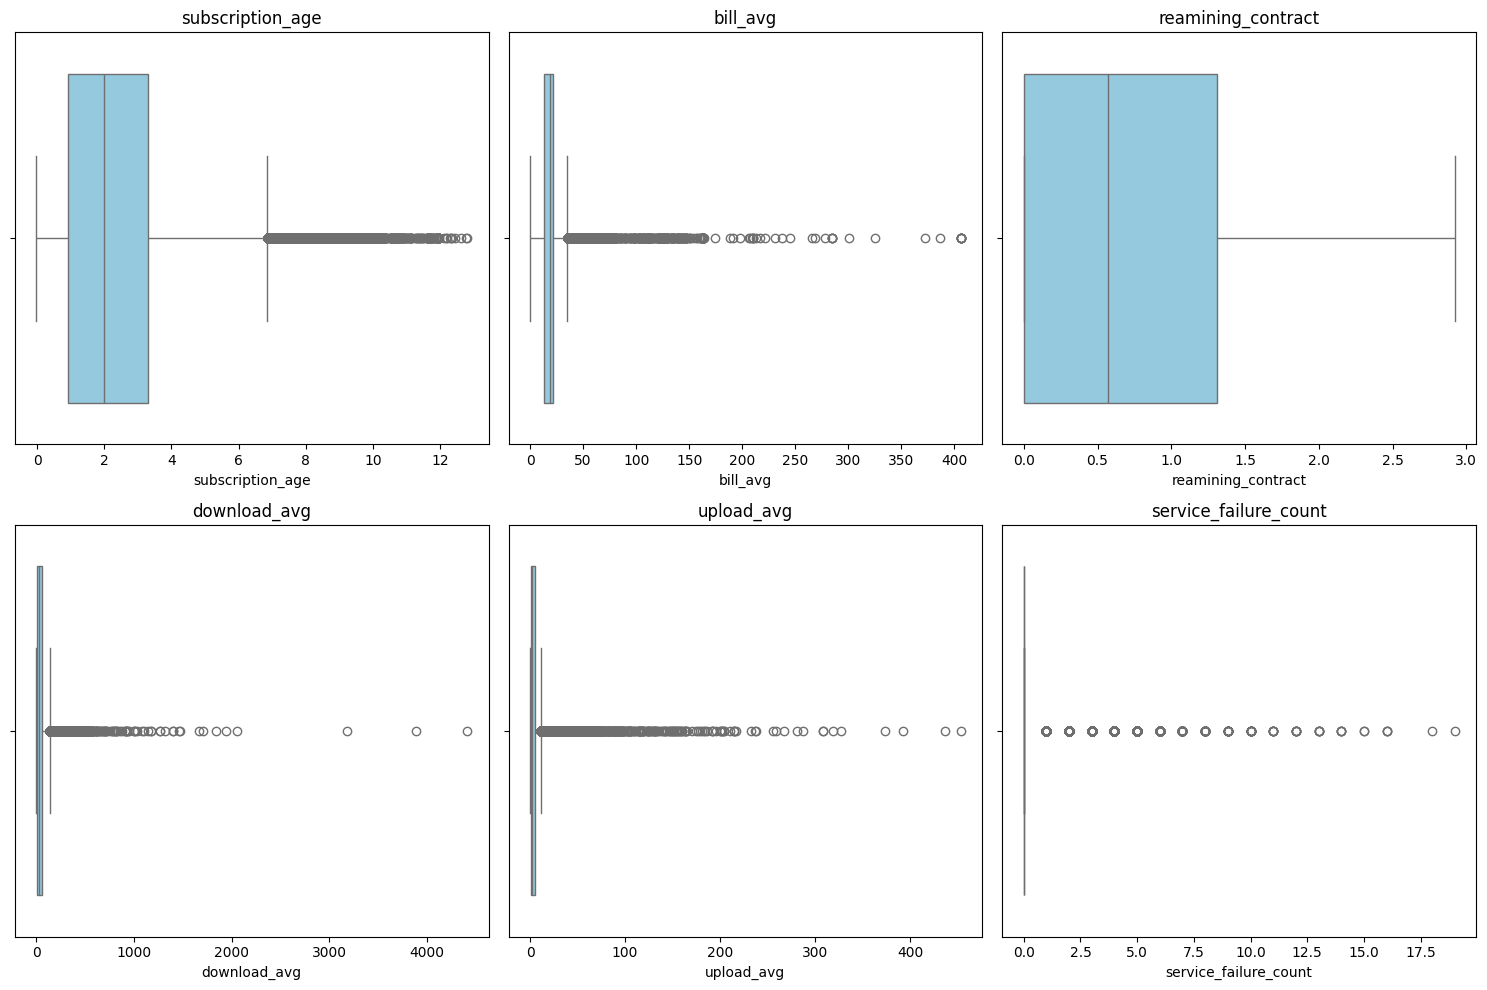

In [ ]:
# Візуалізуємо розподіл даних та діапазон значень для речових ознак
num_features = [
    'subscription_age',
    'bill_avg',
    'reamining_contract',
    'download_avg',
    'upload_avg',
    'service_failure_count'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f'{col}', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Визначення кількості викидів
um_features = ['subscription_age', 'bill_avg', 'reamining_contract', 'service_failure_count', 'download_avg', 'upload_avg', 'download_over_limit']
for col in num_features:
  # пошук кордонів викидів
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  # кількість викидів за межами кордонів
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(f"{col}: {len(outliers)} outliers")


subscription_age: 3175 outliers
bill_avg: 3363 outliers
reamining_contract: 0 outliers
download_avg: 3473 outliers
upload_avg: 4864 outliers
service_failure_count: 11867 outliers


### **Аналіз викидів:**

Перевірили основні речові ознаки на викиди за допомогою IQR-методу та boxplot.
Більшість ознак мають невелику кількість викидів щодо загальної вибірки (5-7%).
Винятком є ​**​service_failure_count**, де кількість рідкісних екстремальних подій сягає ~16%.
Ці викиди можуть являти собою реальні аномалії користувачів, тому їх видалення не рекомендується.


## Досліджуємо вплив ознак на цільову змінну (Churn)

# 1. Вплив категоріальних ознак відтік(churn)

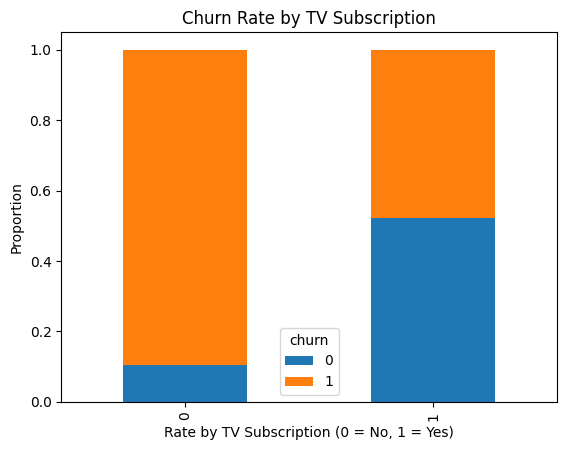

In [ ]:
# is_tv_subscriber на відтік(churn)
ct = pd.crosstab(df['is_tv_subscriber'], df['churn'], normalize='index')

ct.plot(kind='bar', stacked=True)
plt.title('Churn Rate by TV Subscription')
plt.xlabel('Rate by TV Subscription (0 = No, 1 = Yes)')
plt.ylabel('Proportion')
plt.show()

In [ ]:
pd.crosstab(df['is_tv_subscriber'], df['churn'], normalize='index')

churn,0,1
is_tv_subscriber,,
0,0.103805,0.896195
1,0.523370,0.476630


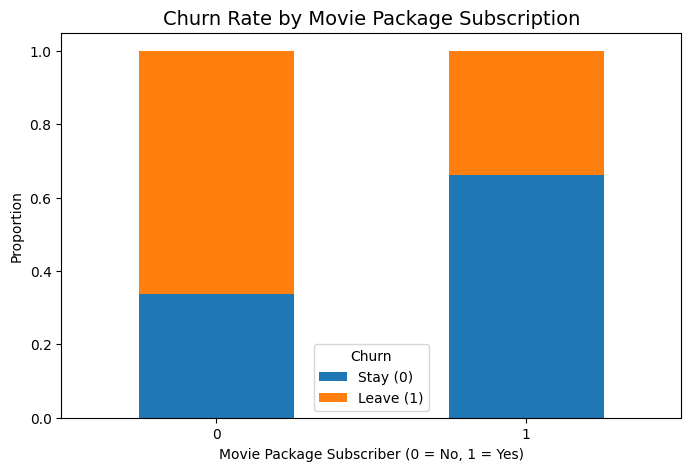

In [ ]:
# is_movie_package_subscriber на відтік(churn)
ct = pd.crosstab(df['is_movie_package_subscriber'],df['churn'],normalize='index')
ct.plot(kind='bar',stacked=True,figsize=(8,5))

plt.title('Churn Rate by Movie Package Subscription', fontsize=14)
plt.xlabel('Movie Package Subscriber (0 = No, 1 = Yes)')
plt.ylabel('Proportion')

plt.legend(title='Churn', labels=['Stay (0)', 'Leave (1)'])
plt.xticks(rotation=0)

plt.show()

In [ ]:
pd.crosstab(df['is_movie_package_subscriber'], df['churn'], normalize='index')

churn,0,1
is_movie_package_subscriber,,
0,0.337582,0.662418
1,0.661154,0.338846


# 2. Вплив дискретних ознак відтік(churn)

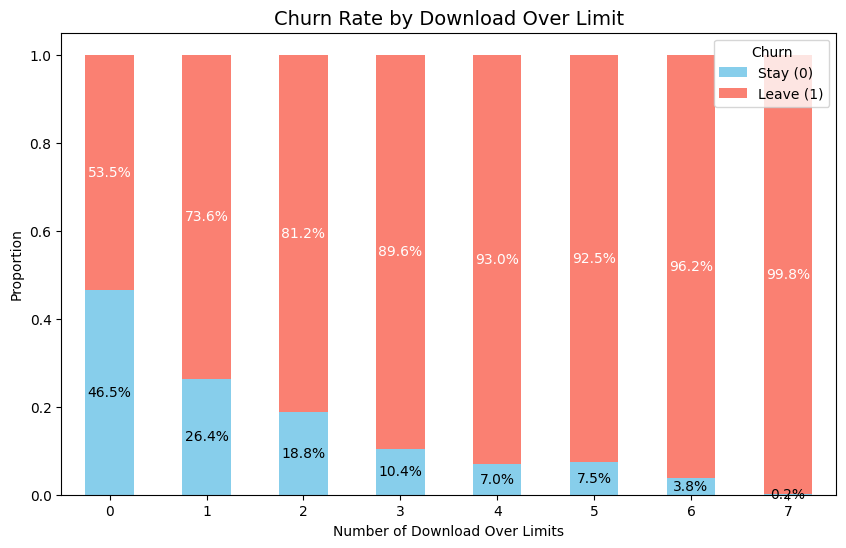

In [ ]:
# Вплив download_over_limit на відтік(churn)

ct = pd.crosstab(df['download_over_limit'], df['churn'], normalize='index')
ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['skyblue', 'salmon']
)

plt.title('Churn Rate by Download Over Limit', fontsize=14)
plt.xlabel('Number of Download Over Limits')
plt.ylabel('Proportion')
plt.legend(title='Churn', labels=['Stay (0)', 'Leave (1)'])
plt.xticks(rotation=0)

for i, row in enumerate(ct.values):
    plt.text(i, row[0]/2, f"{row[0]*100:.1f}%", ha='center', va='center', color='black', fontsize=10)
    plt.text(i, row[0]+row[1]/2, f"{row[1]*100:.1f}%", ha='center', va='center', color='white', fontsize=10)

plt.show()

In [ ]:
pd.crosstab(df['download_over_limit'], df['churn'], normalize='index')

churn,0,1
download_over_limit,,
0,0.464716,0.535284
1,0.263708,0.736292
2,0.187500,0.812500
3,0.104418,0.895582
4,0.070175,0.929825
5,0.074592,0.925408
6,0.037791,0.962209
7,0.001984,0.998016


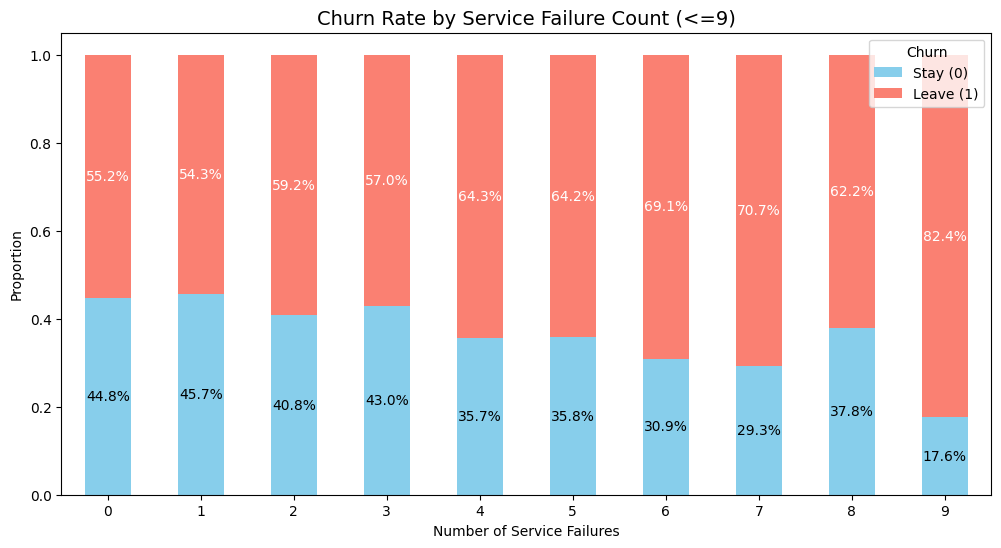

In [ ]:
# Вплив download_service_failure_count на відтік(churn)
df_trim = df[df['service_failure_count'] <= 9]

ct_failures_trim = pd.crosstab(df_trim['service_failure_count'], df_trim['churn'], normalize='index')

ct_failures_trim.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['skyblue', 'salmon']
)

plt.title('Churn Rate by Service Failure Count (<=9)', fontsize=14)
plt.xlabel('Number of Service Failures')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['Stay (0)', 'Leave (1)'])

# Подписи процентов
for i, row in enumerate(ct_failures_trim.values):
    plt.text(i, row[0]/2, f"{row[0]*100:.1f}%", ha='center', va='center', color='black', fontsize=10)
    plt.text(i, row[0]+row[1]/2, f"{row[1]*100:.1f}%", ha='center', va='center', color='white', fontsize=10)

plt.show()

Аналіз нормалізованого розподілу категоріальних ознак показав для:

**is_tv_subscriber** , **is_movie_package_subscriber** - що користувачі з підпискою на ТV  і підпискою на фільми мають меншу частку відтоку, порівняно з користувачами без підписки.Це свідчить про позитивний вплив додаткового сервісу для утримання клієнтів.

Аналіз нормалізованого розподілу для дискретних ознак показав для:

**download_over_limit** : Чим частіше перевищується ліміт, тим вище частка тих, що пішли.

**service_failure_count** Технічні проблеми також є причинами до відтоку.

# 3. Вплив речових ознак на відтік(churn)

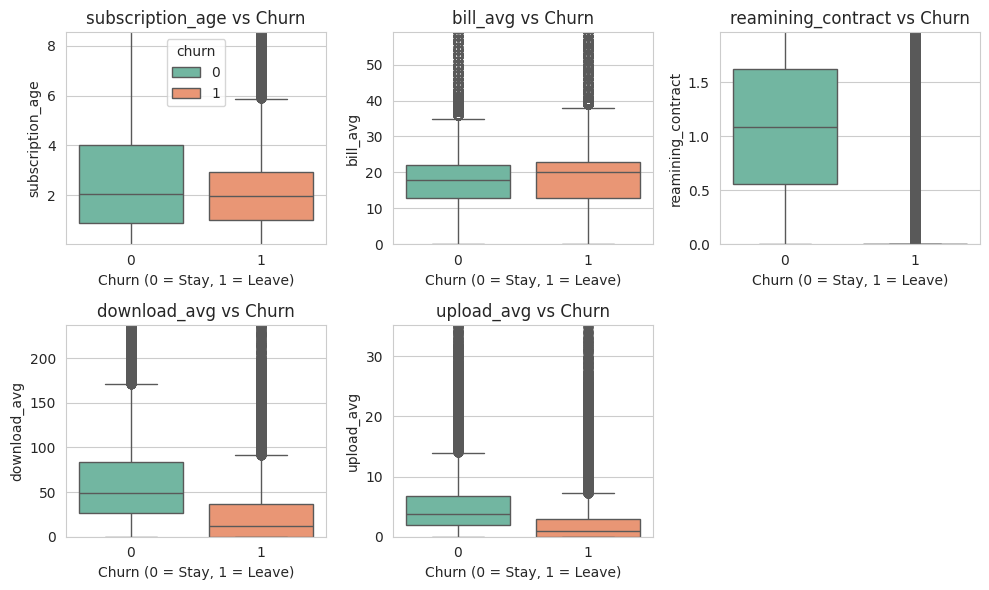

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

num_features = [
    'subscription_age',
    'bill_avg',
    'reamining_contract',
    'download_avg',
    'upload_avg',

]

plt.figure(figsize=(10, 6))

for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)


    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    sns.boxplot(
        data=df,
        x='churn',
        y=col,
        hue='churn',
        palette='Set2',
        dodge=False,
        # showfliers=False
    )

    plt.ylim(lower, upper)

    plt.title(f'{col} vs Churn', fontsize=12)
    plt.xlabel('Churn (0 = Stay, 1 = Leave)')
    plt.ylabel(col)

    if i != 1:
        plt.legend([],[], frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
df.groupby('churn')[num_features].median()

,subscription_age,bill_avg,reamining_contract,download_avg,upload_avg
churn,,,,,
0,2.05,18.0,1.08,48.8,3.7
1,1.97,20.0,0.00,11.9,0.9


### Аналіз медіанних значень речових ознак показав, що найбільш значущими факторами відтоку є:

**remaining_contract** — клієнти у яких закінчується підписка, частіше йдуть. Активна підписка знижує вірогідність відтоку

**download_avg та upload_avg** — низька активність користувача (низький трафік) також пов'язана з високим відтоком

Всі івнші ознаки мають незначний вплив на відток

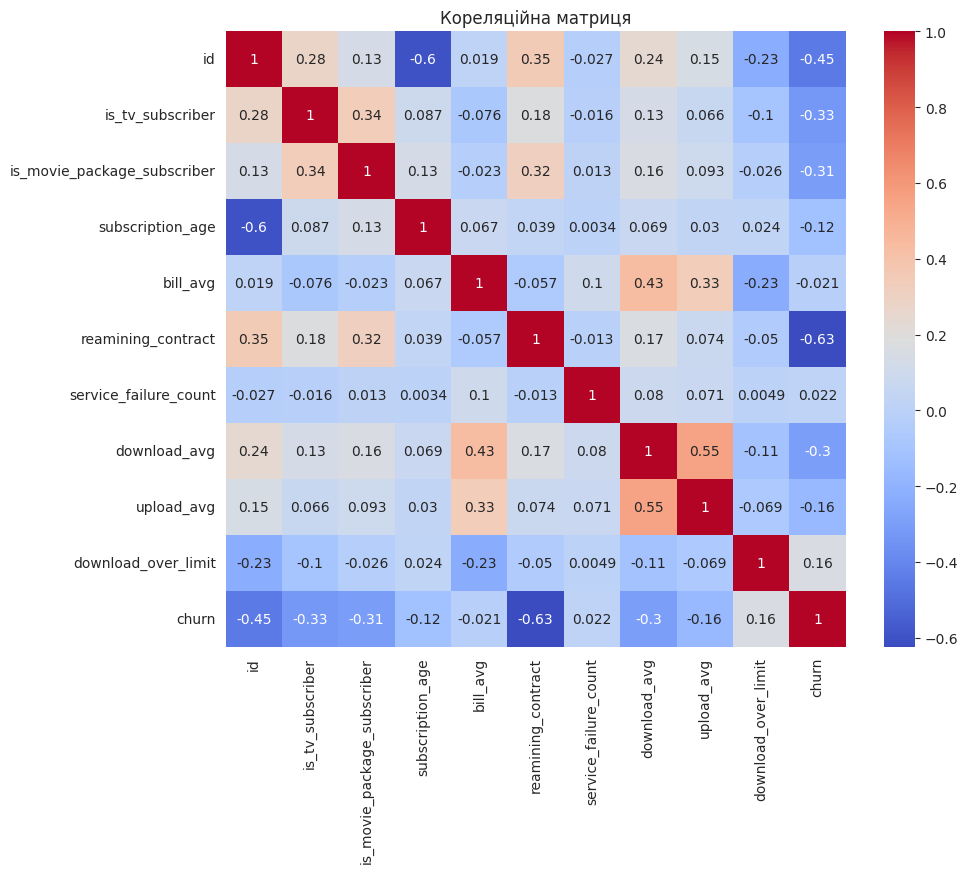

In [ ]:
# Кореляція між  ознаками

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Кореляційна матриця")
plt.show()

Мультиколлінеарності між ознаками не виявлено , що дозволяє використовувати більшість ознак в моделі.

In [ ]:
# корреляція цільової змінної churn з вхідними ознаками
corr = df.corr(numeric_only=True)

corr['churn'].sort_values(ascending=False)

,churn
churn,1.000000
download_over_limit,0.158318
service_failure_count,0.021575
bill_avg,-0.021058
subscription_age,-0.122441
upload_avg,-0.162690
download_avg,-0.298063
is_movie_package_subscriber,-0.307167
is_tv_subscriber,-0.327582
id,-0.451142


In [ ]:
 # кореляція ознаки reamining_contract з цільовою ознакою churn
df[['reamining_contract', 'churn']].corr()

,reamining_contract,churn
reamining_contract,1.00000,-0.62545
churn,-0.62545,1.00000


# **ВИСНОВКИ EDA:**
1. У даних є пропуски в ознаці **remaining_contract** (21572) Також є невелика кількість пропусків в ознаках  **download_avg** і **upload_avg** (381). Це потрібно враховувати на етапі Preprocessing даних
2. Кореляційний аналіз показав, що найбільший вплив на відтік має ознака reamining_contract, що демонструє сильну негативну кореляцію (-0.62), що свідчить про зниження ймовірності відтоку за наявності контракту у клієнта. Чим більше залишилося часу за контрактом тим менша ймовірність відтоку.
3. **download_avg та upload_avg** — низька активність користувача (низький трафік) також пов'язана з високим відтоком
4. Відсутність у клієнта підписки на додаткові сервіси **is_tv_subscriber** і **is_movie_package_subscriber** теж мають суттєвий вплив.
5. Спостерігаються викиди у деяких ознаках. Для ознак із сильно скошеним розподілом (наприклад, bill_avg, download_avg, upload_avg) можна в подальшому розглянути прийом логарифмування



# **PREPROCESSING**

In [ ]:
df_processed = df.copy()

In [ ]:
# Перевіримо пропущені знаечння
df_processed.isna().sum()

,0
id,0
is_tv_subscriber,0
is_movie_package_subscriber,0
subscription_age,0
bill_avg,0
reamining_contract,21572
service_failure_count,0
download_avg,381
upload_avg,381
download_over_limit,0


In [ ]:
df_processed.isna().sum() / df.shape[0] * 100

,0
id,0.000000
is_tv_subscriber,0.000000
is_movie_package_subscriber,0.000000
subscription_age,0.000000
bill_avg,0.000000
reamining_contract,29.847525
service_failure_count,0.000000
download_avg,0.527161
upload_avg,0.527161
download_over_limit,0.000000


У даних є пропущені значення в ознаці **remaining_contract** → 21572
що становить 29,8% пропущених значень від усього датасету. Видалення користувачів з відсутніми значеннями цієї ознаки може негативно вплинути на метрики моделей.

В ознаці **reamining_contract** присутні як нульові значення (0.00),так і пропуски (NaN)

Нульові значення інтерпретуються як випадки, коли контракт у клієнта був, але вже завершився (термін, що залишився, дорівнює 0).

На основі бізнес-логіки та структури даних припустимо, що пропуски NaN в **remaining_contract** відповідають відсутності контракту у клієнта. Для перевірки цієї гіпотези створимо додаткову бінарну ознаку **no_contract** де означає
1 → у клієнта немає контракта , 0 → у клієнта є контракт, що дозволяє моделі враховувати факт наявності чи відсутності контракту.

Для ознаки **reamining_contract** замінимо NaN на 0 щоб не втратити інформацію про відсутність контракту за ознакою no_contract.

Разом **no_contract** і **reamining_contract** дають моделі повну інформацію про контракт

Ознаки **download_avg** і **upload_avg** → 381 пропуск що становить 0,52% від усього датасету тому користувачів з пропущеними значенями для цих ознак можна видалити, оскільки їхня кількість дуже незначна.
заверешенню терміну контракту

#### Створимо окрему бінарну ознаку no_contract, щоб зафіксувати факт відсутності/наявності контракту (0- є котракт, 1-немає )

In [ ]:
df_processed['no_contract'] = df_processed['reamining_contract'].isna().astype(int)
df_processed

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,no_contract
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
72269,1689648,1,1,0.09,0,1.25,0,0.0,0.0,0,1,0
72270,1689676,1,0,0.06,1,1.63,0,0.8,0.0,0,1,0
72271,1689679,1,0,0.02,0,2.19,0,1.5,0.2,0,1,0
72272,1689733,0,0,0.01,0,0.72,0,0.0,0.0,0,1,0


In [ ]:
# Заповнимо пропущені значення в reamining_contract нулями
df_processed['reamining_contract'] = df_processed['reamining_contract'].fillna(0)
df_processed

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,no_contract
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0
1,18,0,0,8.22,0,0.00,0,0.0,0.0,0,1,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0
3,27,0,0,6.87,21,0.00,1,0.0,0.0,0,1,1
4,34,0,0,6.39,0,0.00,0,0.0,0.0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
72269,1689648,1,1,0.09,0,1.25,0,0.0,0.0,0,1,0
72270,1689676,1,0,0.06,1,1.63,0,0.8,0.0,0,1,0
72271,1689679,1,0,0.02,0,2.19,0,1.5,0.2,0,1,0
72272,1689733,0,0,0.01,0,0.72,0,0.0,0.0,0,1,0


In [ ]:
# Видалимо пропущені значення для цих ознак download_avg і upload_avg
df_processed = df_processed.dropna(subset=['download_avg', 'upload_avg'])
df_processed.isna().sum()

,0
id,0
is_tv_subscriber,0
is_movie_package_subscriber,0
subscription_age,0
bill_avg,0
reamining_contract,0
service_failure_count,0
download_avg,0
upload_avg,0
download_over_limit,0


Таким чином створили нову категоріальну ознаку **no_contract** —  (0-є контракт, 1 - немає)
**reamining_contract** — зробили стовпець повністю числовим, NaN замінені на 0


In [ ]:
# Логарифмування ознак із сильним розкидом (bill_avg, upload_avg, download_avg)
log_features = ['bill_avg', 'upload_avg', 'download_avg']

for col in log_features:
    df_processed.loc[:, col + '_log'] = np.log1p(df_processed[col])

df_processed[log_features + [col + '_log' for col in log_features]].head()

,bill_avg,upload_avg,download_avg,bill_avg_log,upload_avg_log,download_avg_log
0,25,2.3,8.4,3.258097,1.193922,2.240710
1,0,0.0,0.0,0.000000,0.000000,0.000000
2,16,0.9,13.7,2.833213,0.641854,2.687847
3,21,0.0,0.0,3.091042,0.000000,0.000000
4,0,0.0,0.0,0.000000,0.000000,0.000000


In [ ]:
df_processed

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,no_contract,bill_avg_log,upload_avg_log,download_avg_log
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0,3.258097,1.193922,2.240710
1,18,0,0,8.22,0,0.00,0,0.0,0.0,0,1,1,0.000000,0.000000,0.000000
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0,2.833213,0.641854,2.687847
3,27,0,0,6.87,21,0.00,1,0.0,0.0,0,1,1,3.091042,0.000000,0.000000
4,34,0,0,6.39,0,0.00,0,0.0,0.0,0,1,1,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72269,1689648,1,1,0.09,0,1.25,0,0.0,0.0,0,1,0,0.000000,0.000000,0.000000
72270,1689676,1,0,0.06,1,1.63,0,0.8,0.0,0,1,0,0.693147,0.000000,0.587787
72271,1689679,1,0,0.02,0,2.19,0,1.5,0.2,0,1,0,0.000000,0.182322,0.916291
72272,1689733,0,0,0.01,0,0.72,0,0.0,0.0,0,1,0,0.000000,0.000000,0.000000


In [ ]:
df_processed.to_csv("../data/processed/telecom_churn_processed.csv", index=False)

В блоці preprocessing зробили копію вихідного датасету, щоб зберегти оригінальні дані.
Потім обробили пропуски і створили додаткову ознаку no_contract, логічно пов'язану з reamining_contract.
Після цього обробили викиди через логарифмування і тепер можна переходити до preprocessing для моделей та підготовки даних для навчання.

# Підготовка даних до навчання моделей

**Категоріальні (0/1):**

- is_tv_subscriber
- is_movie_package_subscriber
- no_contract

**Числові:**
- subscription_age
- bill_avg_log
- upload_avg_log
- download_avg_log
- reamining_contract

**Числові (дискретні):**

- service_failure_count
- download_over_limit

Дискретні ознаки **download_over_limit** і **service_failure_count** залишено у числовому вигляді, оскільки вони відображають кількісні характеристики (частоту перевищень ліміту і кількість збоїв ). Для моделей на основі дерев порядок значень не є проблемою, тому додаткове кодування не застосовувалося.

In [ ]:
df_processed = pd.read_csv("../data/processed/telecom_churn_processed.csv")


In [ ]:
df_processed

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,no_contract,bill_avg_log,upload_avg_log,download_avg_log
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0,3.258097,1.193922,2.240710
1,18,0,0,8.22,0,0.00,0,0.0,0.0,0,1,1,0.000000,0.000000,0.000000
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0,2.833213,0.641854,2.687847
3,27,0,0,6.87,21,0.00,1,0.0,0.0,0,1,1,3.091042,0.000000,0.000000
4,34,0,0,6.39,0,0.00,0,0.0,0.0,0,1,1,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71888,1689648,1,1,0.09,0,1.25,0,0.0,0.0,0,1,0,0.000000,0.000000,0.000000
71889,1689676,1,0,0.06,1,1.63,0,0.8,0.0,0,1,0,0.693147,0.000000,0.587787
71890,1689679,1,0,0.02,0,2.19,0,1.5,0.2,0,1,0,0.000000,0.182322,0.916291
71891,1689733,0,0,0.01,0,0.72,0,0.0,0.0,0,1,0,0.000000,0.000000,0.000000


In [ ]:
df_model = df_processed.copy()

Для числових ознак з великим розкидом і викидами bill_avg , upload_avg, download_avg використовувалися логарифмовані версії, тому вихідні ознаки видаляємо , щоб уникнути мультиколлінеарності.

In [ ]:
# видаляємо старі ознаки
df_model = df_model.drop(['bill_avg', 'upload_avg', 'download_avg'], axis=1)


In [ ]:
df_model

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,reamining_contract,service_failure_count,download_over_limit,churn,no_contract,bill_avg_log,upload_avg_log,download_avg_log
0,15,1,0,11.95,0.14,0,0,0,0,3.258097,1.193922,2.240710
1,18,0,0,8.22,0.00,0,0,1,1,0.000000,0.000000,0.000000
2,23,1,0,8.91,0.00,0,0,1,0,2.833213,0.641854,2.687847
3,27,0,0,6.87,0.00,1,0,1,1,3.091042,0.000000,0.000000
4,34,0,0,6.39,0.00,0,0,1,1,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
71888,1689648,1,1,0.09,1.25,0,0,1,0,0.000000,0.000000,0.000000
71889,1689676,1,0,0.06,1.63,0,0,1,0,0.693147,0.000000,0.587787
71890,1689679,1,0,0.02,2.19,0,0,1,0,0.000000,0.182322,0.916291
71891,1689733,0,0,0.01,0.72,0,0,1,0,0.000000,0.000000,0.000000


In [ ]:
# Розділення на train/test
from sklearn.model_selection import train_test_split

X = df_model.drop(['id','churn'], axis=1)
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Нормалізація числових ознак які впливають на churn та які доцільно масштабувати:

from sklearn.preprocessing import StandardScaler

num_features = ['subscription_age', 'bill_avg_log', 'upload_avg_log', 'download_avg_log', 'service_failure_count', 'reamining_contract','download_over_limit']

scaler = StandardScaler()

X_train[num_features] = scaler.fit_transform(X_train[num_features])

X_test[num_features] = scaler.transform(X_test[num_features])

In [ ]:
# !pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00



🔹 Навчаємо і зберігаємо модель: LogisticRegression

Classification Report для LogisticRegression:

              precision    recall  f1-score   support

           0       0.88      0.85      0.87      6369
           1       0.89      0.91      0.90      8010

    accuracy                           0.89     14379
   macro avg       0.89      0.88      0.88     14379
weighted avg       0.89      0.89      0.89     14379



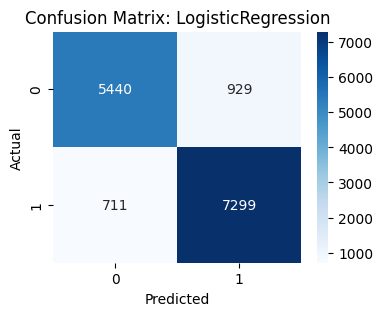


🔹 Навчаємо і зберігаємо модель: RandomForest

Classification Report для RandomForest:

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      6369
           1       0.96      0.94      0.95      8010

    accuracy                           0.94     14379
   macro avg       0.94      0.94      0.94     14379
weighted avg       0.94      0.94      0.94     14379



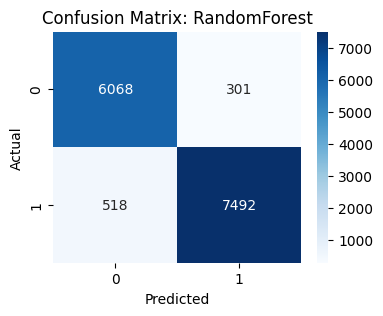


🔹 Навчаємо і зберігаємо модель: GradientBoosting

Classification Report для GradientBoosting:

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      6369
           1       0.96      0.93      0.95      8010

    accuracy                           0.94     14379
   macro avg       0.94      0.94      0.94     14379
weighted avg       0.94      0.94      0.94     14379



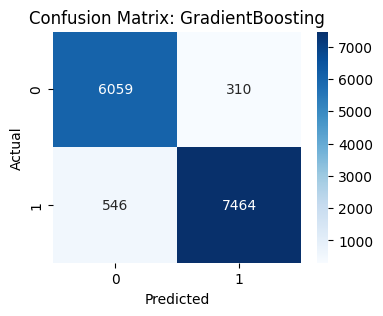


🔹 Навчаємо і зберігаємо модель: XGBoost

Classification Report для XGBoost:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      6369
           1       0.96      0.94      0.95      8010

    accuracy                           0.94     14379
   macro avg       0.94      0.95      0.94     14379
weighted avg       0.95      0.94      0.94     14379



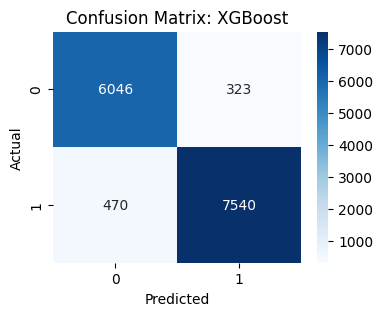


🔹 Навчаємо і зберігаємо модель: LightGBM

Classification Report для LightGBM:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      6369
           1       0.96      0.94      0.95      8010

    accuracy                           0.94     14379
   macro avg       0.94      0.95      0.94     14379
weighted avg       0.95      0.94      0.95     14379



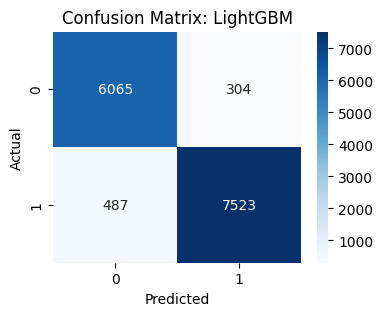


🔹 Навчаємо і зберігаємо модель: CatBoost

Classification Report для CatBoost:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      6369
           1       0.96      0.94      0.95      8010

    accuracy                           0.95     14379
   macro avg       0.94      0.95      0.94     14379
weighted avg       0.95      0.95      0.95     14379



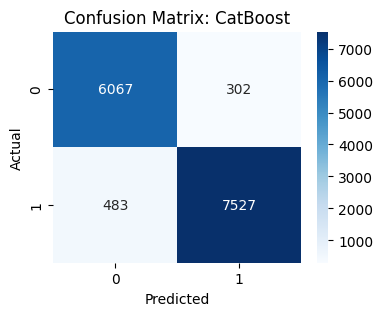

✅ X_train , X_test , y_train , y_test збережені для подальшого тюнінгу моделей


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Словник моделей
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# Stratified KFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    print(f"\n🔹 Навчаємо і зберігаємо модель: {name}")

    start_time = time.time()
    model.fit(X_train, y_train)
    joblib.dump(model, f"../models/{name}.joblib")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC-AUC (test)
    roc_auc = roc_auc_score(y_test, y_proba)


    cv_score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc'
    ).mean()


    elapsed_time = time.time() - start_time


    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "model": name,
        "accuracy": report["accuracy"],
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"],
        "roc_auc": roc_auc,
        "cv_roc_auc": cv_score,
        "time_sec": elapsed_time
    })


    print(f"\nClassification Report для {name}:\n")
    print(classification_report(y_test, y_pred))


    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
joblib.dump(X_train, "../models/X_train.joblib")
joblib.dump(X_test, "../models/X_test.joblib")
joblib.dump(y_train, "../models/y_train.joblib")
joblib.dump(y_test, "../models/y_test.joblib")
joblib.dump(X_train.columns.tolist(), "../models/feature_names.joblib")

print("✅ X_train , X_test , y_train , y_test збережені для подальшого тюнінгу моделей")



In [ ]:
results_df = pd.DataFrame(results).sort_values(by="roc_auc", ascending=False)

print("\n📊 Порівняння моделей:")
print(results_df)




📊 Порівняння моделей:
                model  accuracy  precision    recall        f1   roc_auc  \
3             XGBoost  0.944850   0.958922  0.941323  0.950041  0.982515   
5            CatBoost  0.945406   0.961425  0.939700  0.950439  0.982500   
4            LightGBM  0.944989   0.961160  0.939201  0.950054  0.982033   
1        RandomForest  0.943042   0.961376  0.935331  0.948174  0.981733   
2    GradientBoosting  0.940469   0.960123  0.931835  0.945768  0.973759   
0  LogisticRegression  0.885945   0.887093  0.911236  0.899002  0.941530   

   cv_roc_auc   time_sec  
3    0.980831   4.983458  
5    0.981134  95.049648  
4    0.980878   4.464718  
1    0.980143  55.997573  
2    0.973851  31.956765  
0    0.940327   3.476713  


In [ ]:
results_df.to_csv("../models/models_summary.csv", index=False)
print("📊 models_summary.csv is save  ✅")

📊 models_summary.csv is save  ✅


In [ ]:
xgb_model = joblib.load("../models/XGBoost.joblib")
lgb_model = joblib.load("../models/LightGBM.joblib")
X_train = joblib.load("../models/X_train.joblib")
y_train = joblib.load("../models/y_train.joblib")

In [ ]:
# візуалізація важливості ознак(feature_importances) топ моделей
def plot_feature_importance(model, features, model_name, top_n=None):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        fi_df = pd.DataFrame({
            'feature': features,
            'importance': importances
        }).sort_values(by='importance', ascending=False)

        if top_n is None or top_n > len(fi_df):
            top_n = len(fi_df)

        print(f"\nТоп {top_n} ознак для {model_name}:\n")
        print(fi_df.head(top_n))

        # Візуалізація
        plt.figure(figsize=(10,6))
        sns.barplot(x='importance', y='feature', data=fi_df.head(top_n), palette='viridis')
        plt.title(f'Feature Importance: {model_name}')
        plt.show()
    else:
        print(f"{model_name} не підтримує feature_importances_")

In [ ]:
feature_names = X_train.columns.tolist()


Топ 10 ознак для XGBoost:

                       feature  importance
3           reamining_contract    0.586633
6                  no_contract    0.201361
9             download_avg_log    0.055218
0             is_tv_subscriber    0.028887
7                 bill_avg_log    0.027923
5          download_over_limit    0.027490
2             subscription_age    0.022944
1  is_movie_package_subscriber    0.021863
8               upload_avg_log    0.016645
4        service_failure_count    0.011035


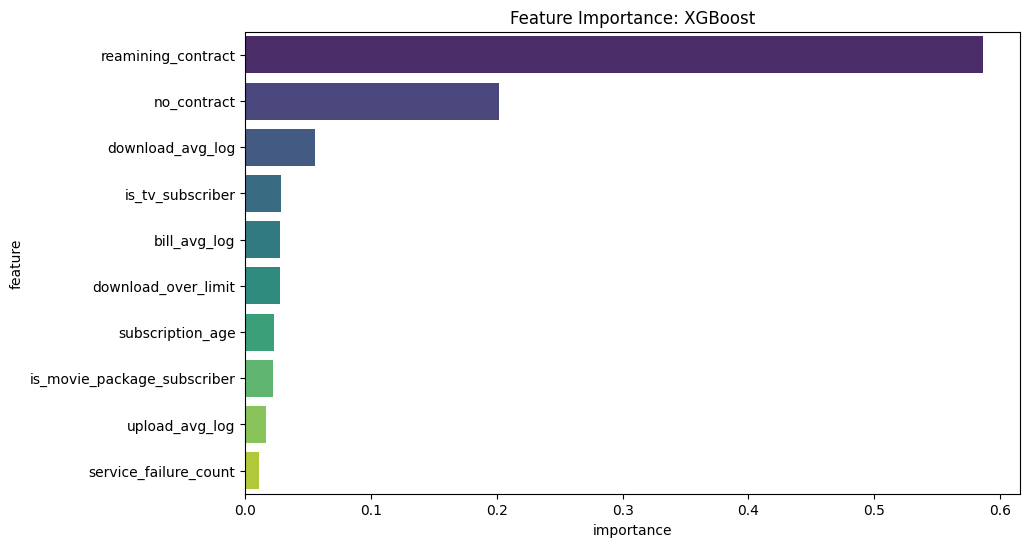

In [ ]:
# Візуалізація для XGBoost
plot_feature_importance(xgb_model, feature_names, "XGBoost")


Топ 10 ознак для LightGBM:

                       feature  importance
7                 bill_avg_log         811
2             subscription_age         654
3           reamining_contract         608
9             download_avg_log         384
8               upload_avg_log         222
6                  no_contract          86
1  is_movie_package_subscriber          78
5          download_over_limit          62
0             is_tv_subscriber          55
4        service_failure_count          40


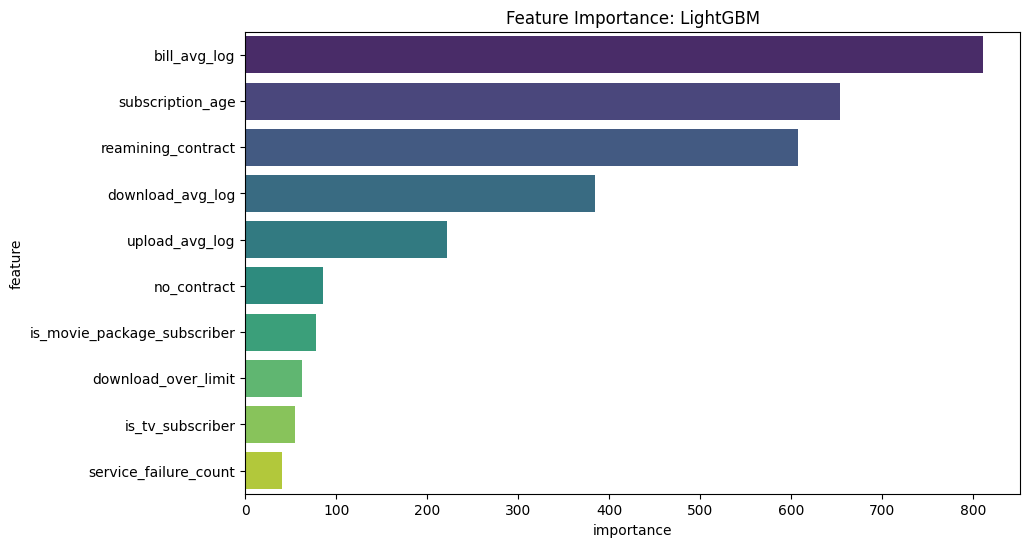

In [ ]:
# Візуалізація LightGBM
plot_feature_importance(lgb_model, feature_names, "LightGBM")

# **Висновки**:

**Logistic Regression** показала найнижчі метрики серед усіх моделей
(F1 0.899, ROC-AUC 0.941)

**Gradient Boosting** трохи поступається іншим моделям(F1 0.946, ROC-AUC 0.974)  

**Random Forest**
Стабільно високі метрики але трохи поступаюється бустинговим моделям (F1 0.948, ROC-AUC 0.980)

Всі бустингові моделі (**XGBoost, LightGBM, CatBoost**) показують практично однакову якість (F1 0,950, ROC-AUC 0,982) однак CatBoost значно повільніший за інші , при цьому не дає приросту якості.

**LightGBM** та **XGBoost** показують майжде однакові результати

Доцільно вибрати XGBoost и LightGBM для оптимізації гіперпараметрів.

# **TUNING Models LightGBM та XGBoost**

##  GridSearchCV для XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# 🔹 Настройка кросс-валидации
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 🔹 XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}

xgb_grid = GridSearchCV(
    xgb_model,
    param_grid=xgb_param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)
print("✅Найкращі параметри XGBoost:", xgb_grid.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
✅Найкращі параметри XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
# збереження XGBoost з найкращими параметрами
best_xgb = xgb_grid.best_estimator_

joblib.dump(best_xgb, "../models/XGBoost_best.joblib")
joblib.dump(xgb_grid.best_params_, "../models/XGBoost_best_params.joblib")

print("✅ Найкраща модель XGBoost збережена")

✅ Найкраща модель XGBoost збережена


## GridSearchCV для LightGBM

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 🔹 кросс-валидация
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 🔹LightGBM
lgb_model = LGBMClassifier(random_state=42, verbose=-1)

lgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [-1, 5, 7],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50, 63],
    'subsample': [0.7, 0.8, 1],
}

lgb_grid = GridSearchCV(
    lgb_model,
    param_grid=lgb_param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
lgb_grid.fit(X_train, y_train)

print("✅ Найкраща модель LightGBM:", lgb_grid.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
✅ Найкраща модель LightGBM: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 63, 'subsample': 0.7}


In [ ]:
# збереження LightGBM з найкращими параметрами
best_lgb = lgb_grid.best_estimator_

joblib.dump(best_lgb, "../models/LightGBM_best.joblib")
joblib.dump(lgb_grid.best_params_, "../models/LightGBM_best_params.joblib")

print("✅ Найкраща модель LightGBM збережена")

✅ Найкраща модель LightGBM збережена


In [ ]:
# Завантажуємо найкращі моделі LightGBM і XGBoost
best_xgb = joblib.load("../models/XGBoost_best.joblib")
best_lgb = joblib.load("../models/LightGBM_best.joblib")
# завантажуємо тестові дані
X_test = joblib.load("../models/X_test.joblib")
y_test = joblib.load("../models/y_test.joblib")

In [ ]:
# Функція оцінки модели
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n🔹 {name}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))

    return roc_auc

# Вибір найкращої моделі між XGBoost і LightGBM

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
xgb_score = evaluate_model(best_xgb, X_test, y_test, "XGBoost")
lgb_score = evaluate_model(best_lgb, X_test, y_test, "LightGBM")

if xgb_score > lgb_score:
    best_model = best_xgb
    best_name = "XGBoost"
else:
    best_model = best_lgb
    best_name = "LightGBM"

print(f"\n🏆 Найкраща модель: {best_name}")


🔹 XGBoost
ROC-AUC: 0.9833
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      6369
           1       0.96      0.94      0.95      8010

    accuracy                           0.94     14379
   macro avg       0.94      0.95      0.94     14379
weighted avg       0.95      0.94      0.94     14379


🔹 LightGBM
ROC-AUC: 0.9835
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      6369
           1       0.96      0.94      0.95      8010

    accuracy                           0.95     14379
   macro avg       0.94      0.95      0.95     14379
weighted avg       0.95      0.95      0.95     14379


🏆 Найкраща модель: LightGBM


**Висновки:**

Для кожної моделі було проведено підбір гіперпараметрів за допомогою GridSearchCV.
Обидві моделі демонструють дуже високу якість:

**ROC-AUC** = 0.983

**Accuracy** = 0.94–0.95

**F1-score** = 0.94–0.95

Так як різниця була мінімальною була вибрана LightGBM через більш високу швидкість та ефективність.

In [ ]:
joblib.dump(best_model, "../models/final_model_LightGBM.joblib")
print("✅Найкраща модель: LightGBM збережена ")

✅Найкраща модель: LightGBM збережена 


# Перевірка прогнозу на тестових даних


📊Фінальні метрики на тестовій вибірці:
Accuracy:  0.9460
Precision: 0.9609
Recall:    0.9414
F1-score:  0.9511
ROC-AUC:   0.9835


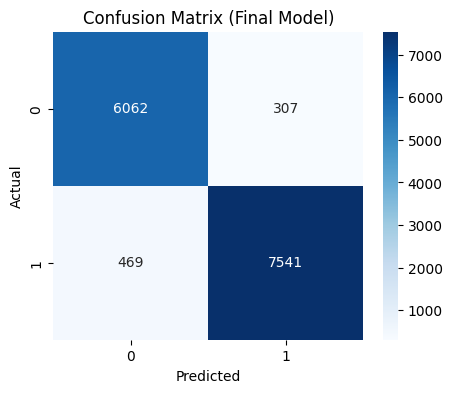

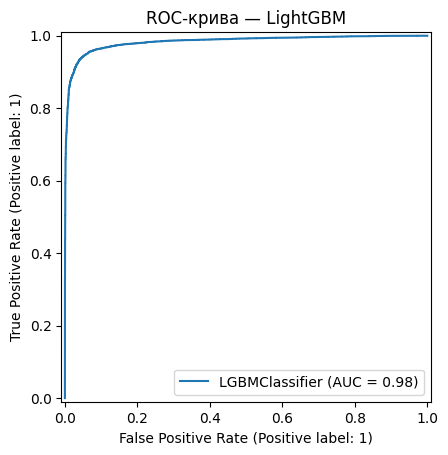


Приклад передбачення для нового клієнта:
Prediction (0-stay, 1=leave): [1]
Probability of churn: [0.99964796]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
# Завантажуємо фінальну модель та тестові дані
best_model = joblib.load("../models/final_model_LightGBM.joblib")
X_test = joblib.load("../models/X_test.joblib")
y_test = joblib.load("../models/y_test.joblib")

# 🔹 Передбачення
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 🔹 Метрики
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print("\n📊Фінальні метрики на тестовій вибірці:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc:.4f}")

# 🔹 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Final Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 🔹 ROC Curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC-крива — LightGBM")
plt.show()

# 🔹 Edge case (передбачення для нового клієнта)
new_client = X_test.iloc[[5]]
prediction = best_model.predict(new_client)
probability = best_model.predict_proba(new_client)[:, 1]

print("\nПриклад передбачення для нового клієнта:")
print("Prediction (0-stay, 1=leave):", prediction)
print("Probability of churn:", probability)